# Feature Detection & Matching with ORB

## What is ORB?

**ORB** (Oriented FAST and Rotated BRIEF) is a fast, free feature detector that:

- Detects **keypoints** (distinctive points) in images
- Creates **binary descriptors** (256-bit codes) for matching
- Works well for real-time applications
- Handles rotation and scale changes

**Why ORB?** It's 100x faster than SIFT, free (no patents), and perfect for robotics, mobile apps, and real-time video processing.

## Import Required Libraries

Let's start by importing the necessary libraries.

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)

## Keypoint Detection with ORB

A **keypoint** is a detected feature with:
- **Position** (x, y) - Where the feature is
- **Scale** - Feature size
- **Orientation** - Direction it points
- **Response** - Detection confidence

Let's detect keypoints in an image.

## Keypoint Detection with ORB

### What are Keypoints?

A **keypoint** is a detected feature location with:
- **Position** `(x, y)` - Where the feature is
- **Scale** `size` - How large the feature is
- **Orientation** `angle` - Which direction the feature points
- **Response** value - How strong/confident the detection is

Let's detect keypoints in an image.

Number of keypoints detected: 375
Descriptor shape: (375, 32)
Descriptor dtype: uint8

First 5 keypoints details:
Keypoint 0:
  Position (x, y): (550.0, 70.0)
  Size (scale): 31.0
  Orientation (angle): 90.0°
  Response (strength): 0.00

Keypoint 1:
  Position (x, y): (520.0, 100.0)
  Size (scale): 31.0
  Orientation (angle): 180.0°
  Response (strength): 0.00

Keypoint 2:
  Position (x, y): (550.0, 130.0)
  Size (scale): 31.0
  Orientation (angle): 90.0°
  Response (strength): 0.00

Keypoint 3:
  Position (x, y): (50.4, 50.4)
  Size (scale): 37.2
  Orientation (angle): 224.8°
  Response (strength): 0.00

Keypoint 4:
  Position (x, y): (88.8, 50.4)
  Size (scale): 37.2
  Orientation (angle): 313.4°
  Response (strength): 0.01



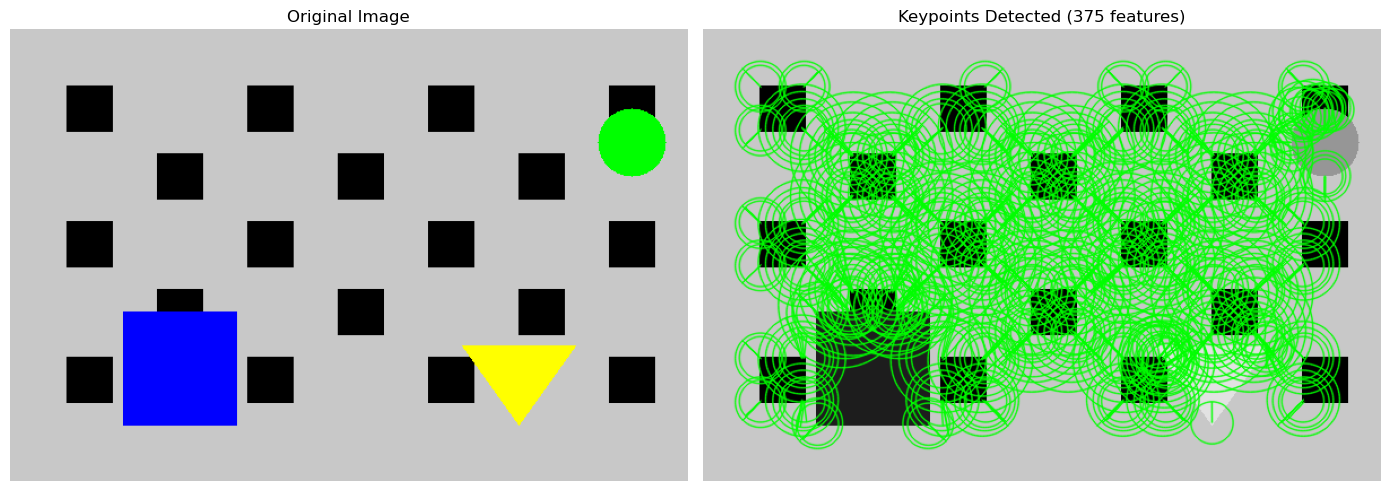

In [7]:
# Create a test image with distinctive features (or use a real image)
# For this example, we'll create a synthetic image with patterns
test_image = np.zeros((400, 600, 3), dtype=np.uint8)
test_image[:] = (200, 200, 200)  # Gray background

# Add various features
# Checkerboard pattern
for i in range(5):
    for j in range(7):
        if (i + j) % 2 == 0:
            x, y = 50 + j * 80, 50 + i * 60
            cv2.rectangle(test_image, (x, y), (x+40, y+40), (0, 0, 0), -1)

# Add some shapes with distinct features
cv2.circle(test_image, (550, 100), 30, (0, 255, 0), -1)
cv2.rectangle(test_image, (100, 250), (200, 350), (255, 0, 0), -1)
triangle_pts = np.array([[400, 280], [500, 280], [450, 350]], np.int32)
cv2.fillPoly(test_image, [triangle_pts], (0, 255, 255))

# Convert to grayscale for feature detection
gray_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2GRAY)

# Create ORB detector
orb = cv2.ORB_create(nfeatures=500, fastThreshold=20)

# Detect keypoints and compute descriptors
keypoints, descriptors = orb.detectAndCompute(gray_image, None)

print(f"Number of keypoints detected: {len(keypoints)}")
print(f"Descriptor shape: {descriptors.shape}")
print(f"Descriptor dtype: {descriptors.dtype}\n")

# Display keypoint information
print("First 5 keypoints details:")
print("=" * 80)
for i, kp in enumerate(keypoints[:5]):
    print(f"Keypoint {i}:")
    print(f"  Position (x, y): ({kp.pt[0]:.1f}, {kp.pt[1]:.1f})")
    print(f"  Size (scale): {kp.size:.1f}")
    print(f"  Orientation (angle): {kp.angle:.1f}°")
    print(f"  Response (strength): {kp.response:.2f}")
    print()

# Visualize keypoints
image_with_keypoints = cv2.drawKeypoints(gray_image, keypoints, None, 
                                         color=(0, 255, 0),
                                         flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(image_with_keypoints, cmap='gray')
axes[1].set_title(f'Keypoints Detected ({len(keypoints)} features)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Feature Descriptors

A **descriptor** is a compact representation of a feature:
- **256-bit binary code** (32 bytes)
- Compared using **Hamming distance** (count of differing bits)
- Lower distance = Better match

In [8]:
# Visualize descriptors
print(f"Keypoints: {len(keypoints)}")
print(f"Descriptor shape: {descriptors.shape}")
print(f"Descriptor type: {descriptors.dtype} (binary)\n")

# Hamming distance example
if len(descriptors) >= 2:
    xor = np.bitwise_xor(descriptors[0], descriptors[1])
    hamming_dist = np.unpackbits(xor).sum()
    print(f"Example: Hamming distance between descriptor 0 and 1 = {hamming_dist}/2048 bits")

Keypoints: 375
Descriptor shape: (375, 32)
Descriptor type: uint8 (binary)

Example: Hamming distance between descriptor 0 and 1 = 71/2048 bits


## Feature Matching

**Feature Matching** finds corresponding keypoints between images.

**Key concept: Lowe's Ratio Test**
- Compare each feature's distance to nearest vs 2nd-nearest match
- If `distance_to_1st / distance_to_2nd < 0.75` → Good match
- Filters out ambiguous/false matches

Image 1: 375 keypoints
Image 2: 468 keypoints

Total possible matches: 375
Matches after Lowe's ratio test: 125
Filtering efficiency: 33.3% of candidates passed

Top 5 matches:
------------------------------------------------------------
Match 0:
  Image 1 keypoint: index 0, pos (550.0, 70.0)
  Image 2 keypoint: index 73, pos (310.0, 487.0)
  Hamming distance: 15.0

Match 1:
  Image 1 keypoint: index 1, pos (520.0, 100.0)
  Image 2 keypoint: index 63, pos (284.0, 462.0)
  Hamming distance: 5.0

Match 2:
  Image 1 keypoint: index 2, pos (550.0, 130.0)
  Image 2 keypoint: index 63, pos (284.0, 462.0)
  Hamming distance: 5.0

Match 3:
  Image 1 keypoint: index 9, pos (549.6, 69.6)
  Image 2 keypoint: index 73, pos (310.0, 487.0)
  Hamming distance: 14.0

Match 4:
  Image 1 keypoint: index 10, pos (542.4, 70.8)
  Image 2 keypoint: index 72, pos (309.0, 481.0)
  Hamming distance: 10.0



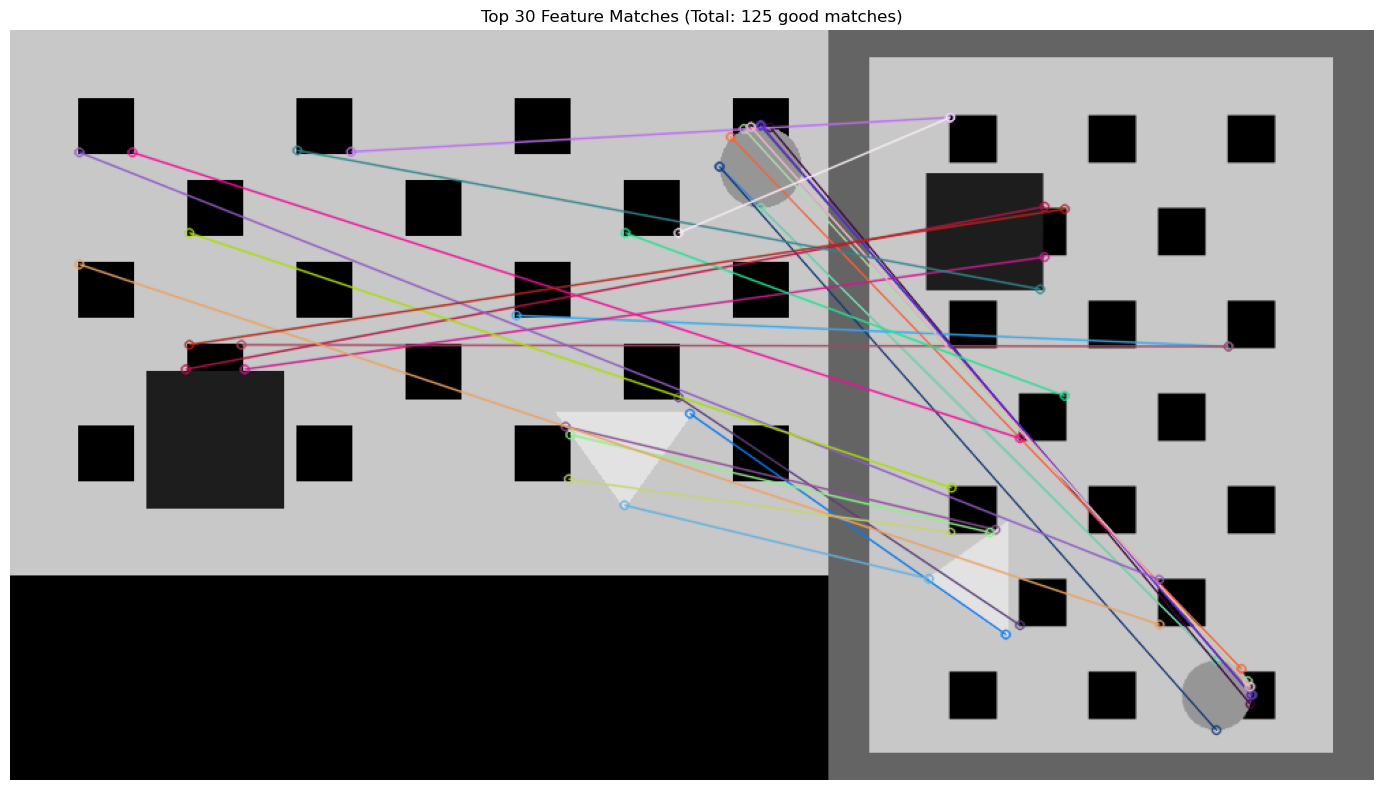

In [9]:
# Create two similar images (one is a modified version of the other)
image1 = test_image.copy()
gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)

# Create image2: Same content but rotated and scaled slightly
image2 = cv2.rotate(image1, cv2.ROTATE_90_CLOCKWISE)
image2 = cv2.resize(image2, None, fx=0.85, fy=0.85)
image2 = cv2.copyMakeBorder(image2, 20, 20, 30, 30, cv2.BORDER_CONSTANT, value=(100,100,100))
gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

# Detect features in both images
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

print(f"Image 1: {len(kp1)} keypoints")
print(f"Image 2: {len(kp2)} keypoints\n")

# Create BFMatcher (Brute Force Matcher)
# For ORB (binary descriptors), use cv2.NORM_HAMMING
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

# Match features using knnMatch to get top-2 matches for Lowe's ratio test
matches = bf.knnMatch(des1, des2, k=2)

print(f"Total possible matches: {len(matches)}")

# Apply Lowe's ratio test to filter matches
good_matches = []
for match_pair in matches:
    if len(match_pair) == 2:
        m, n = match_pair
        # Lowe's ratio test: 0.75 is typical threshold
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

print(f"Matches after Lowe's ratio test: {len(good_matches)}")
print(f"Filtering efficiency: {len(good_matches)/len(matches)*100:.1f}% of candidates passed\n")

# Display match details
print(f"Top 5 matches:")
print("-" * 60)
for i, match in enumerate(good_matches[:5]):
    kp1_idx = match.queryIdx
    kp2_idx = match.trainIdx
    distance = match.distance
    
    print(f"Match {i}:")
    print(f"  Image 1 keypoint: index {kp1_idx}, pos ({kp1[kp1_idx].pt[0]:.1f}, {kp1[kp1_idx].pt[1]:.1f})")
    print(f"  Image 2 keypoint: index {kp2_idx}, pos ({kp2[kp2_idx].pt[0]:.1f}, {kp2[kp2_idx].pt[1]:.1f})")
    print(f"  Hamming distance: {distance}")
    print()

# Visualize matches
img_matches = cv2.drawMatches(gray1, kp1, gray2, kp2, good_matches[:30], 
                              None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(16, 8))
plt.imshow(img_matches, cmap='gray')
plt.title(f'Top 30 Feature Matches (Total: {len(good_matches)} good matches)')
plt.axis('off')
plt.tight_layout()
plt.show()

## Practical Applications: Logo Detection

### Application Overview

**Logo Detection** uses feature matching to find company logos or brand symbols in images. Common use cases:

- 📸 Detect logos in photos and videos
- 🏢 Monitor brand presence on social media
- 🎥 Automatic content tagging in videos
- 📊 Competitive analysis and market research

### How It Works

1. **Store logo image** - Create database of known logos
2. **Extract features** - Detect ORB features in query image
3. **Match features** - Find corresponding features between query and logo
4. **Count matches** - If enough matches → logo found!
5. **Estimate pose** - Use matches to find logo location and orientation

Logo Detection Example
Logo features: 14
Scene features: 500

Potential matches: 14
Good matches (after filtering): 4
Detection confidence: 28.6%

 LOGO DETECTED!


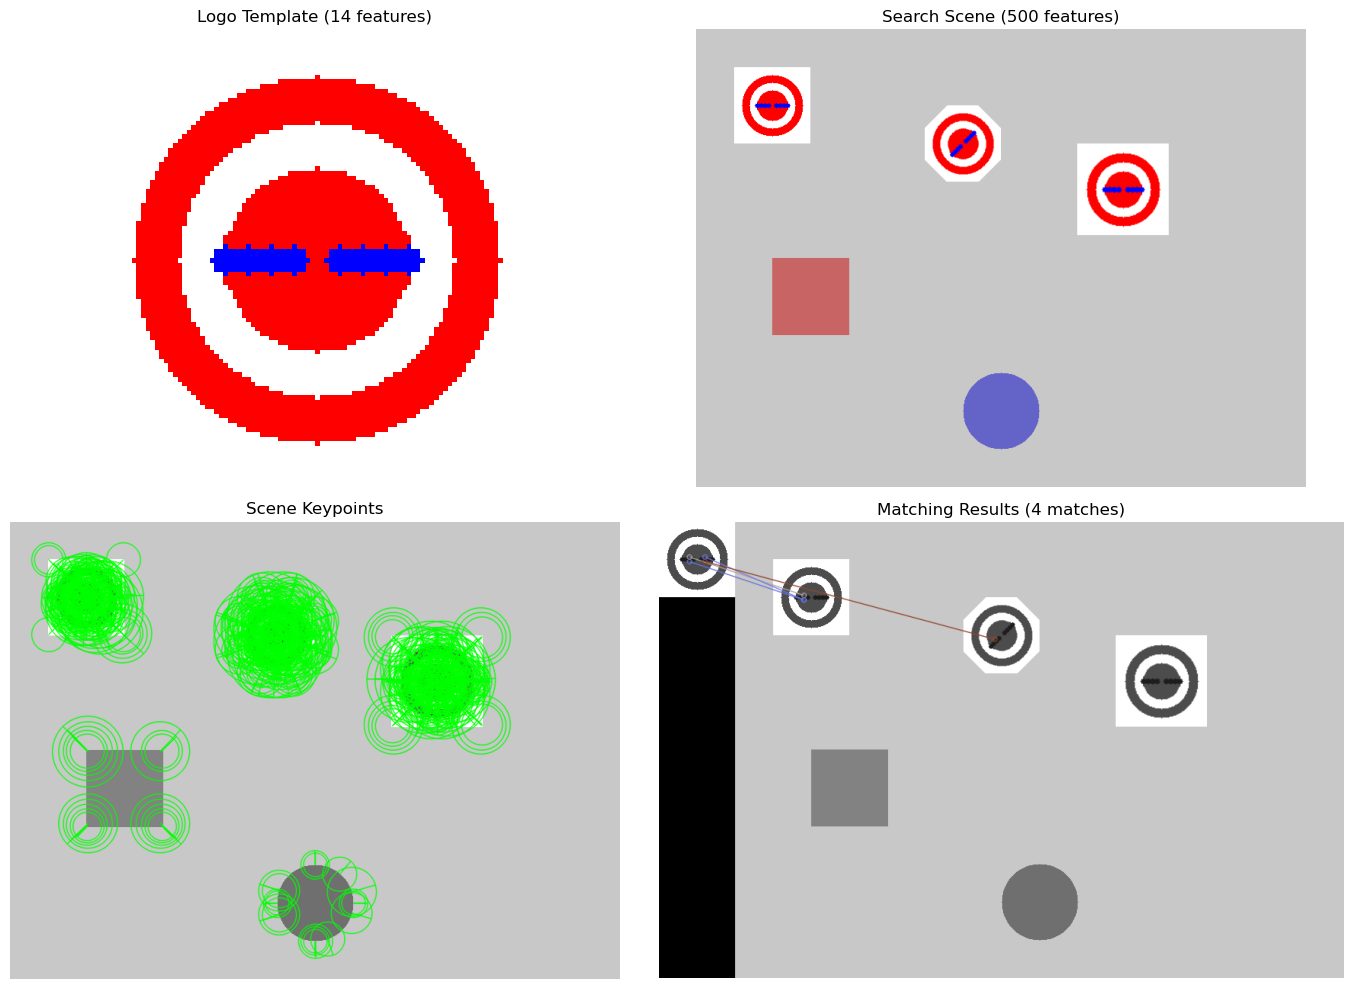

In [10]:
# Create a synthetic logo with more texture/features
logo = np.ones((100, 100, 3), dtype=np.uint8) * 255

# Draw more distinctive shapes to create keypoints
cv2.circle(logo, (50, 50), 40, (0, 0, 255), -1)
cv2.circle(logo, (50, 50), 30, (255, 255, 255), -1)
cv2.circle(logo, (50, 50), 20, (0, 0, 255), -1)  # Add inner circle for more features
cv2.rectangle(logo, (30, 45), (70, 55), (0, 0, 255), -1)

# Add some texture details
for i in range(5, 25, 5):
    cv2.circle(logo, (50 - i, 50), 3, (255, 0, 0), -1)
    cv2.circle(logo, (50 + i, 50), 3, (255, 0, 0), -1)

# Create scene with logo
scene = np.ones((600, 800, 3), dtype=np.uint8) * 200

# Place original logo
x, y = 50, 50
scene[y:y+100, x:x+100] = logo

# Place rotated logo
(h, w) = logo.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, 45, 1.0)
logo_rotated = cv2.warpAffine(logo, M, (w, h), borderValue=(200, 200, 200))
x, y = 300, 100
if y + h <= scene.shape[0] and x + w <= scene.shape[1]:
    scene[y:y+h, x:x+w] = logo_rotated

# Place scaled logo
logo_scaled = cv2.resize(logo, (120, 120))
x, y = 500, 150
scene[y:y+120, x:x+120] = logo_scaled

# Add random objects
cv2.rectangle(scene, (100, 300), (200, 400), (100, 100, 200), -1)
cv2.circle(scene, (400, 500), 50, (200, 100, 100), -1)

# Convert to grayscale
gray_logo = cv2.cvtColor(logo, cv2.COLOR_BGR2GRAY)
gray_scene = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)

# Detect features
kp_logo, des_logo = orb.detectAndCompute(gray_logo, None)
kp_scene, des_scene = orb.detectAndCompute(gray_scene, None)

print("Logo Detection Example")
print("=" * 60)
print(f"Logo features: {len(kp_logo)}")
print(f"Scene features: {len(kp_scene)}\n")

# Match features
bf_matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
good_matches = []

if des_logo is not None and des_scene is not None and len(des_logo) > 0 and len(des_scene) > 0:
    matches = bf_matcher.knnMatch(des_logo, des_scene, k=2)
    
    for match_pair in matches:
        if len(match_pair) == 2:
            m, n = match_pair
            if m.distance < 0.75 * n.distance:
                good_matches.append(m)
    
    print(f"Potential matches: {len(matches)}")
    print(f"Good matches (after filtering): {len(good_matches)}")
    if len(kp_logo) > 0:
        print(f"Detection confidence: {len(good_matches) / len(kp_logo) * 100:.1f}%\n")
    
    MIN_MATCH_COUNT = 4
    if len(good_matches) >= MIN_MATCH_COUNT:
        print(" LOGO DETECTED!")
    else:
        print(" Logo not found (insufficient matches)")
else:
    print(" No features detected in logo or scene")

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(cv2.cvtColor(logo, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title(f'Logo Template ({len(kp_logo)} features)')
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title(f'Search Scene ({len(kp_scene)} features)')
axes[0, 1].axis('off')

img_scene_kp = cv2.drawKeypoints(gray_scene, kp_scene, None, color=(0, 255, 0),
                                  flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
axes[1, 0].imshow(img_scene_kp, cmap='gray')
axes[1, 0].set_title('Scene Keypoints')
axes[1, 0].axis('off')

if len(good_matches) > 0:
    img_matches = cv2.drawMatches(gray_logo, kp_logo, gray_scene, kp_scene,
                                  good_matches[:20], None,
                                  flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    axes[1, 1].imshow(img_matches, cmap='gray')
    axes[1, 1].set_title(f'Matching Results ({len(good_matches)} matches)')
else:
    axes[1, 1].text(0.5, 0.5, 'No matches found', ha='center', va='center',
                    transform=axes[1, 1].transAxes, fontsize=14, color='red')
    axes[1, 1].set_title('Matching Results')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


## Summary: Key Concepts

### 1. Keypoints
Detected distinctive points with position (x, y), scale, orientation, and strength

### 2. Descriptors
256-bit binary codes capturing feature appearance - compared using Hamming distance

### 3. Feature Matching Workflow
```python
# Create ORB detector
orb = cv2.ORB_create(nfeatures=500)

# Detect keypoints & descriptors
kp, des = orb.detectAndCompute(gray_image, None)

# Match features
bf = cv2.BFMatcher(cv2.NORM_HAMMING)
matches = bf.knnMatch(des1, des2, k=2)

# Apply Lowe's ratio test (filter false matches)
good = [m for m, n in matches if m.distance < 0.75 * n.distance]
```

### 4. Applications
- Logo detection: Find logos in images
- Template matching: Locate objects at different scales/rotations
- AR markers: Detect and track markers for content overlay

## Tips & Best Practices

**Preprocessing:**
- Convert to grayscale (feature detectors work on intensity)
- Use `cv2.createCLAHE()` to normalize illumination if needed

**Parameter Tuning:**
```python
orb = cv2.ORB_create(
    nfeatures=500,      # More = slower but more features
    scaleFactor=1.2,    # Larger = detects features at more scales
    nlevels=8           # More = better scale invariance
)
```

**Matching Quality:**
- Use Lowe's ratio test (threshold 0.75) to filter false matches
- Require minimum number of matches before declaring detection

**Common Issues:**
| Problem | Solution |
|---------|----------|
| No features | Image too smooth - add patterns |
| Too many false matches | Increase Lowe's ratio threshold |
| Slow processing | Reduce `nfeatures` or image resolution |

---
